## Allen-Cahn Dynamics

### Configuration

In [1]:
from __init__ import create_config, figures
from IPython.display import display

In [2]:
# Allen-Cahn configuration (baseline - no perturbation)
config = create_config(
    system="allen_cahn",
    n_states=32,
    n_controls=3,
    t1_initial=15.0,
    t1_max=60.0,
)
config_ac = create_config(
    system="allen_cahn",
    n_states=32,
    n_controls=3,
    t1_initial=15.0,
    t1_max=60.0,
    seed=config.seed,
    perturbation_type=None,
    perturbation_strength=1.0,
)

figures.save_config_table(config_ac)
figures.show_spec(
    config_ac, 
    keys=["system", "seed", "n_states", "n_controls", "t1_initial", "perturbation_type"],
    title="Allen-Cahn Configuration"
)

**Allen-Cahn Configuration**

system,seed,n_states,n_controls,t1_initial,perturbation_type
allen_cahn,32,32,3,15.000000,None


### Data Generation

In [3]:
controller_configs_ac = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
}

trajectories,data points,t (min),t (max),|x| (mean),|x| (max),||x|| (mean),||x|| (max)
100,16488,0.000000,5.600864,0.335678,1.718851,0.484973,1.081960


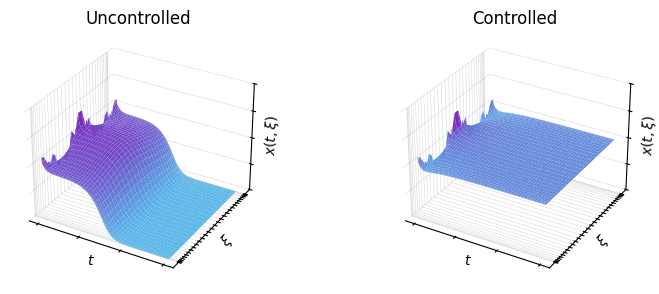

In [4]:
import matplotlib.pyplot as plt
from data import load_or_generate
# Data generation for Allen-Cahn (baseline)
data_ac_train, data_ac_val, meta_ac = load_or_generate(
    config_ac, 
    n_trajectories=100, 
    controller=config_ac.ocp.LQR
)

summary_ac = figures.save_data_summary_table(config_ac, data_ac_train)
display(summary_ac.style.hide(axis="index"))

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### Model Training

**Training Configuration**

sup_epochs,sup_lr,unsup_epochs,unsup_n_steps,unsup_lr,horizon,batch_size,grad_clip
1,0.000010,3,50,0.000500,100,32,None



Training: GradQRNet

Training: GradQRNet (sup)

Training: GradQRNet (pre)

Training: GradQRNet (pre/sup)

Training: GradQRNet (ad)

Training: GradQRNet (sup/ad)


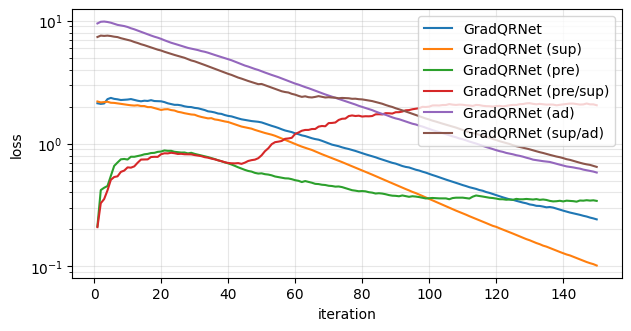

In [5]:
from controls.train import TrainConfig
from controls.model_factory import train_controllers
# Train controllers on baseline Allen-Cahn
cfg_ac = TrainConfig(batch_size=int(config_ac.n_states), unsup_epochs=3, horizon=100, unsup_n_steps=50)

# 1. Save to LaTeX using the new generic function
figures.save_params_table(cfg_ac, "allen_cahn_traincfg.tex", title="Training Configuration", config=config_ac)

# 2. Show in Notebook using the universal show_spec
figures.show_spec(
    cfg_ac, 
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "grad_clip"], 
    title="Training Configuration"
)


trained_models_ac, trained_controllers_ac, histories_ac = train_controllers(
    config=config_ac,
    train_cfg=cfg_ac,
    data=data_ac_train,
    val_data=data_ac_val,
    controller_configs=controller_configs_ac,  # Use the config defined above
)

figures.plot_training_losses(
    series=[(name, hist) for name, hist in histories_ac.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
    savepath="allen_cahn_loss_curve.pdf",
    config=config_ac,
);

### Evaluation: Out-of-Sample Generalization

In [6]:
# Use trained_controllers_ac (Control with eval_U), not trained_models_ac (raw GradNet)
controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
] + [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

In [7]:
controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
] + [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

In [8]:
from simulation import monte_carlo

results = monte_carlo(config.ocp, config, controllers, n_MC=100, dist=1.5)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config)

  1%|          | 1/100 [00:00<00:35,  2.81it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


  2%|▏         | 2/100 [00:00<00:41,  2.39it/s]

Trajectory 1 NOT converged - final_dists[1] = inf


  3%|▎         | 3/100 [00:01<00:44,  2.16it/s]

...

  3%|▎         | 3/100 [00:00<00:17,  5.62it/s]

Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 100/100 [00:13<00:00,  7.64it/s]


Controller,Stability (S),Final ||X|| (mean),t_conv (mean),Cost J (mean)
LQR (Baseline),100.0%,0.0005,10.21,1.3192
GradQRNet,85.0%,0.0065,18.68,1.3974
GradQRNet (sup),4.0%,0.0053,8.54,0.1942
GradQRNet (pre),100.0%,0.0075,16.20,1.2559
GradQRNet (pre/sup),0.0%,N/A,N/A,N/A
GradQRNet (ad),100.0%,0.0003,9.55,1.3351
GradQRNet (sup/ad),100.0%,0.0003,9.51,1.3321


,Model,Stability $S$,$t_{\text{conv}}$ (mean),Cost $J$ (mean)
0,LQR (Baseline),1.00,10.207878,1.319185
1,GradQRNet,0.85,18.675564,1.397441
2,GradQRNet (sup),0.04,8.542637,0.194216
3,GradQRNet (pre),1.00,16.199675,1.255855
4,GradQRNet (pre/sup),0.00,NaN,NaN
5,GradQRNet (ad),1.00,9.553686,1.335130
6,GradQRNet (sup/ad),1.00,9.514543,1.332072


### Evaluation: Robustness

In [9]:
from simulation import monte_carlo, process_robustness_results

perturbation_variants = [
  #  (None, 0.0, "Baseline"),
    ("advection", 0.05, "Advection (c=0.05)"),
   ("advection", 0.10, "Advection (c=0.10)"),
    ("advection", 0.12, "Advection (c=0.12)"),
]

# Prepare controllers (trained on baseline)
controllers_ac = [
    ("LQR", config_ac.ocp.LQR),
] + [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

# Evaluate on each perturbation variant
robustness_results = {}
for pert_type, pert_strength, pert_name in perturbation_variants:
    print(f"\n{'='*60}")
    print(f"Evaluating on: {pert_name} perturbation")
    print(f"{'='*60}")
    
    # Create config for this perturbation variant
    config_eval = create_config(
        system="allen_cahn",
        n_states=32,
        n_controls=3,
        t1_initial=15.0,
        t1_max=60.0,
        seed=config.seed,
        perturbation_type=pert_type,
        perturbation_strength=pert_strength,
    )
    
    # Run Monte Carlo evaluation with baseline-trained controllers
    results = monte_carlo(config_eval.ocp, config_eval, controllers_ac)
    robustness_results[pert_name] = results
    
    # Show results for this variant
    print(f"\nResults on {pert_name}:")
    figures.show_monte_carlo_results(results)


Evaluating on: Advection (c=0.05) perturbation


  1%|          | 1/100 [00:00<00:42,  2.34it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


  2%|▏         | 2/100 [00:00<00:45,  2.16it/s]

Trajectory 1 NOT converged - final_dists[1] = inf


...

  3%|▎         | 3/100 [00:00<00:16,  5.83it/s]

Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 100/100 [00:12<00:00,  8.30it/s]


Results on Advection (c=0.12):


Controller,Stability (S),Final ||X|| (mean),t_conv (mean),Cost J (mean)
LQR,100.0%,0.0003,9.11,0.5028
GradQRNet,66.0%,0.0063,15.88,0.5830
GradQRNet (sup),8.0%,0.0043,7.65,0.0323
GradQRNet (pre),100.0%,0.0063,14.32,0.5274
GradQRNet (pre/sup),0.0%,N/A,N/A,N/A
GradQRNet (ad),100.0%,0.0002,8.52,0.5084
GradQRNet (sup/ad),100.0%,0.0002,8.49,0.5084


In [10]:

controller_names = [name for name, _ in controllers_ac]
robustness_df = process_robustness_results(robustness_results, controller_names)

results = robustness_results
display(robustness_df.style.hide(axis="index"))

# Save to LaTeX
robustness_df.to_latex(
    "allen_cahn_robustness.tex",
    index=False,
    escape=False,
    caption="Perturbation robustness: controllers trained on baseline Allen-Cahn, evaluated on perturbed variants.",
    label="tab:ac-robustness",
)

Controller,Advection (c=0.05) Stab.,Advection (c=0.05) Cost,Advection (c=0.10) Stab.,Advection (c=0.10) Cost,Advection (c=0.12) Stab.,Advection (c=0.12) Cost
LQR,100%,0.54,100%,0.49,100%,0.50
GradQRNet,72%,0.63,73%,0.52,66%,0.58
GradQRNet (sup),7%,0.03,7%,0.03,8%,0.03
GradQRNet (pre),100%,0.57,100%,0.52,100%,0.53
GradQRNet (pre/sup),0%,—,0%,—,0%,—
GradQRNet (ad),100%,0.55,100%,0.49,100%,0.51
GradQRNet (sup/ad),100%,0.55,100%,0.49,100%,0.51


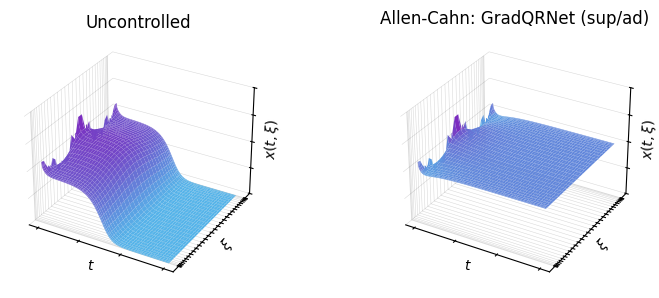

In [11]:
# Best learned controller
best_ctrl_name = list(trained_controllers_ac.keys())[-1]  # typically AdHOC
fig = figures.plot_3d(config=config_ac, controller=trained_controllers_ac[best_ctrl_name], savepath="figures/allen_cahn_adhoc.pdf")
plt.title(f"Allen-Cahn: {best_ctrl_name}")
plt.show()